In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import KFold
from sklearn.metrics import log_loss

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [3]:
m_results = pd.read_csv("../data/march-machine-learning-mania-2026/MRegularSeasonCompactResults.csv")
w_results = pd.read_csv("../data/march-machine-learning-mania-2026/WRegularSeasonCompactResults.csv")

m_seeds = pd.read_csv("../data/march-machine-learning-mania-2026/MNCAATourneySeeds.csv")
w_seeds = pd.read_csv("../data/march-machine-learning-mania-2026/WNCAATourneySeeds.csv")

sample = pd.read_csv("../data/march-machine-learning-mania-2026/SampleSubmissionStage2.csv")

print("Men games:", m_results.shape)
print("Women games:", w_results.shape)
print("Submission rows:", sample.shape)

Men games: (198079, 8)
Women games: (142093, 8)
Submission rows: (132133, 2)


Quick EDA

In [6]:
m_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


In [7]:
w_results.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1998,18,3104,91,3202,41,H,0
1,1998,18,3163,87,3221,76,H,0
2,1998,18,3222,66,3261,59,H,0
3,1998,18,3307,69,3365,62,H,0
4,1998,18,3349,115,3411,35,H,0


In [8]:
m_seeds.head()

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374


In [9]:
w_seeds.head()

,Season,Seed,TeamID
0,1998,W01,3330
1,1998,W02,3163
2,1998,W03,3112
3,1998,W04,3301
4,1998,W05,3272


In [10]:
sample.head()

,ID,Pred
0,2026_1101_1102,0.5
1,2026_1101_1103,0.5
2,2026_1101_1104,0.5
3,2026_1101_1105,0.5
4,2026_1101_1106,0.5


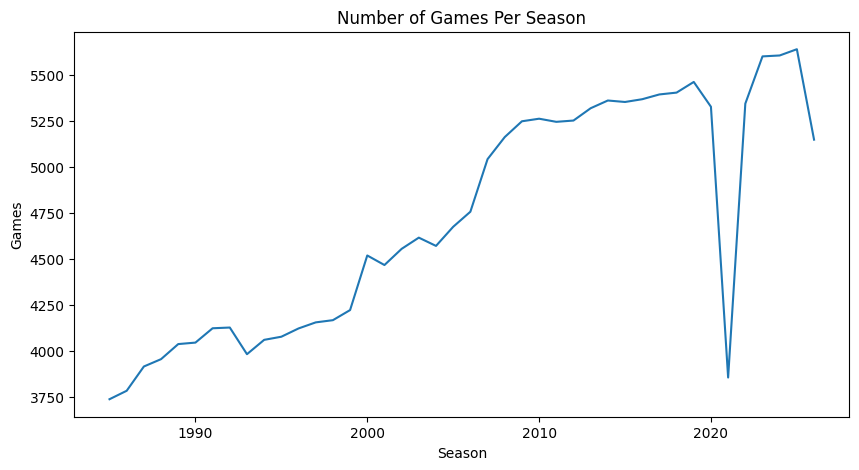

In [5]:
plt.figure(figsize=(10,5))

m_results.groupby("Season").size().plot()

plt.title("Number of Games Per Season")
plt.ylabel("Games")

plt.show()

Score distribution

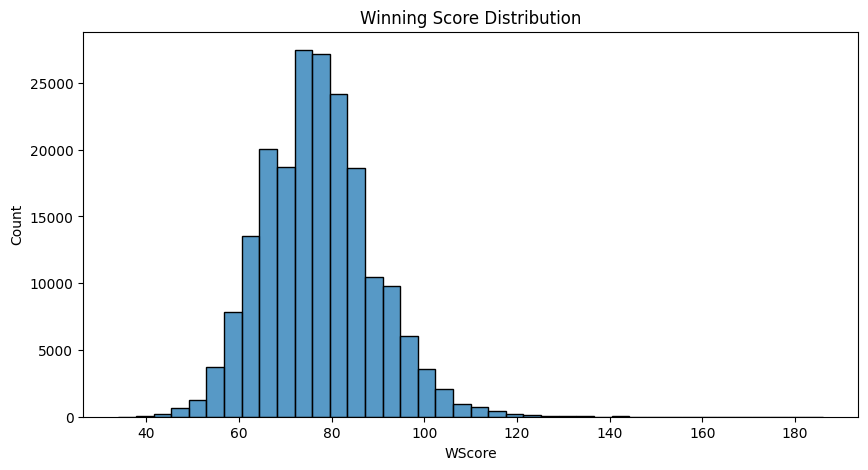

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(m_results["WScore"], bins=40)

plt.title("Winning Score Distribution")

plt.show()

## Elo Rating feature
### Elo capture team strength evolution across the season.

In [22]:


def calculate_elo(df, k=20):
    elo = {}

    for i, row in m_results.iterrows():
        # print(i, row)
        season = row.Season
        w = row.WTeamID
        l = row.LTeamID
        
        if season not in elo:
            elo[season] = {}
        
        for t in [w, l]:
            if t not in elo[season]:
                elo[season][t] = 1500

        r1 = elo[season][w]
        r2 = elo[season][l]

        expected = 1/(1+10**((r2-r1)/400))

        elo[season][w] += k*(1-expected)
        elo[season][l] += k*(0-(1-expected))

    return elo

In [23]:
m_elo = calculate_elo(m_results)
w_elo = calculate_elo(w_results)

Seed Feature

In [24]:
def clean_seed(seed):
    return int(seed[1:3])

In [25]:
m_seeds["SeedNum"] = m_seeds["Seed"].apply(clean_seed)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(clean_seed)

m_seed_dict = dict(zip(zip(m_seeds.Season, m_seeds.TeamID), m_seeds.SeedNum))
w_seed_dict = dict(zip(zip(w_seeds.Season, w_seeds.TeamID), w_seeds.SeedNum))

Win rate Feature

In [26]:
def compute_winrate(df):

    wins = df.groupby(["Season", "WTeamID"]).size()
    losses = df.groupby(["Season", "LTeamID"]).size()

    teams = set(wins.index).union(set(losses.index))

    winrate = {}

    for season, team in teams:

        w = wins.get((season, team), 0)
        l = losses.get((season, team), 0)

        total = w+1 

        if total == 0:
            winrate[(season, team)] = 0.5
        else:
            winrate[(season, team)] = w/total

    return winrate 

In [27]:
m_wr = compute_winrate(m_results)
w_wr = compute_winrate(w_results)

Training Dataset

In [28]:
def build_train(df, elo_dict, seed_dict, wr_dict):

    X = []
    y = []

    for row in tqdm(df.itertuples(), total = len(df)):

        season = row.Season 
        w = row.WTeamID
        l = row.LTeamID 

        elo_w = elo_dict[season].get(w, 1500)
        elo_l = elo_dict[season].get(l, 1500)

        seed_w = seed_dict.get((season, w), 16)
        seed_l = seed_dict.get((season, l), 16)

        wr_w = wr_dict.get((season, w), 0.5)
        wr_l = wr_dict.get((season, l), 0.5)

        X.append([elo_w-elo_l, seed_w-seed_l, wr_w-wr_l])
        y.append(1)

        X.append([elo_l-elo_w, seed_l-seed_w, wr_l-wr_w])
        y.append(0)

    return np.array(X), np.array(y)

In [29]:
Xm, ym = build_train(m_results, m_elo, m_seed_dict, m_wr)
Xw, yw = build_train(w_results, w_elo, w_seed_dict, w_wr)

X = np.vstack([Xm, Xw])
y = np.concatenate([ym, yw])

100%|██████████| 142093/142093 [00:00<00:00, 539535.08it/s]


Model (XGBoost GPU)

In [30]:
model = XGBClassifier(
    n_estimators = 300,
    learning_rate=0.02,
    max_depth=5,

    subsample=0.85,
    colsample_bytree = 0.85,

    min_child_weight=6,

    reg_alpha=1,
    reg_lambda=3,

    tree_method="hist",
    device="cuda",

    eval_metric = "logloss",
    early_stopping_round=200
)

Cross Validation

In [32]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros(len(y))

for fold, (tr, val) in enumerate(kf.split(X)):

    print("Fold:", fold+1)

    model.fit(
        X[tr], y[tr],
        eval_set=[(X[val], y[val])],
        verbose=200
    )

    oof[val] = model.predict_proba(X[val])[:,1]

print("CV LogLoss:", log_loss(y, oof))

Fold: 1
[0]	validation_0-logloss:0.68829
[200]	validation_0-logloss:0.49587
[299]	validation_0-logloss:0.49387
Fold: 2
[0]	validation_0-logloss:0.68829
[200]	validation_0-logloss:0.49623
[299]	validation_0-logloss:0.49434
Fold: 3
[0]	validation_0-logloss:0.68832
[200]	validation_0-logloss:0.49764
[299]	validation_0-logloss:0.49577
Fold: 4
[0]	validation_0-logloss:0.68829
[200]	validation_0-logloss:0.49845
[299]	validation_0-logloss:0.49677
Fold: 5
[0]	validation_0-logloss:0.68831
[200]	validation_0-logloss:0.49885
[299]	validation_0-logloss:0.49710
CV LogLoss: 0.49556828064434827
